<a href="https://colab.research.google.com/github/programadormovel/Gloss2Text-MarianMT/blob/main/tradutor_automatico_marianmt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
!pip install -q transformers datasets evaluate sacrebleu sentencepiece accelerate scikit-learn pandas

In [70]:
import re
import gc
import torch
import pandas as pd
import numpy as np
import evaluate

from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

from transformers import (
    MarianMTModel,
    MarianTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

In [71]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

if device == "cuda":
    print(torch.cuda.get_device_name(0))

Dispositivo: cuda
Tesla T4


In [72]:
csv_path = "/content/pt_br2libras_gloss.csv"

df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)
print("Total:", len(df))

                                               pt-br  \
0  Orientações específicas para solicitações com ...   
1  Qualquer cidadão interessado em visitar a Bibl...   
2  Qualquer cidadão interessado em doar obras par...   
3                       Qualquer cidadão interessado   
4  Qualquer cidadão e/ou empresa brasileira, com ...   

                                        libras-gloss  is_government_source  \
0  ORIENTAÇÃO ESPECÍFICO SOLICITAR OBJETIVO CONTR...                  True   
1  QUALQUER CIDADÃO INTERESSAR VISITAR BIBLIOTECA...                  True   
2  QUALQUER CIDADÃO INTERESSAR DOAR&OBJETO OBRA&L...                  True   
3                        QUALQUER CIDADÃO INTERESSAR                  True   
4  QUALQUER CIDADÃO OU EMPRESA BRASIL&PAÍS CPF OU...                  True   

                                 english_translation  
0  Specific guidelines for requests for the purpo...  
1  Any citizen interested in visiting the Zenaide...  
2  Any citizen interested in 

In [73]:
df = df[["libras-gloss", "pt-br"]].dropna().copy()
df.columns = ["source", "target"]

In [74]:
def normalize_non_manual_tag(tag):
    tag = tag.strip().lower()

    replacements = {
        "interrogação": "interrogacao",
        "interrogacao": "interrogacao",
        "pergunta": "interrogacao",
        "negação": "negacao",
        "negacao": "negacao",
        "neg": "negacao",
        "ponto": "ponto",
        "exclamação": "exclamacao",
        "exclamacao": "exclamacao"
    }

    return replacements.get(tag, tag.replace(" ", "_"))


def normalize_gloss(text):
    text = str(text).strip()

    # Exemplo: [INTERROGAÇÃO] -> <interrogacao>
    text = re.sub(
        r"\[([^\]]+)\]",
        lambda m: f" <{normalize_non_manual_tag(m.group(1))}> ",
        text
    )

    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()

    return text


def normalize_portuguese(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [75]:
df["source"] = df["source"].apply(normalize_gloss)
df["target"] = df["target"].apply(normalize_portuguese)

df = df[
    (df["source"].str.len() > 1) &
    (df["target"].str.len() > 1)
].copy()

print("Total após limpeza:", len(df))
df.head()

Total após limpeza: 127347


,source,target
0,orientação específico solicitar objetivo contr...,Orientações específicas para solicitações com ...
1,qualquer cidadão interessar visitar biblioteca...,Qualquer cidadão interessado em visitar a Bibl...
2,qualquer cidadão interessar doar&objeto obra&l...,Qualquer cidadão interessado em doar obras par...
3,qualquer cidadão interessar,Qualquer cidadão interessado
4,qualquer cidadão ou empresa brasil&país cpf ou...,"Qualquer cidadão e/ou empresa brasileira, com ..."


In [76]:
# df_sample = df.sample(n=30000, random_state=42).copy()

In [77]:
df_sample = df.sample(n=60000, random_state=42).copy()
df_sample = df.copy()

In [78]:
train_df, temp_df = train_test_split(
    df_sample,
    test_size=0.10,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

Treino: 114612
Validação: 6367
Teste: 6368


In [79]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[["source", "target"]],
        preserve_index=False
    ),
    "validation": Dataset.from_pandas(
        val_df[["source", "target"]],
        preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df[["source", "target"]],
        preserve_index=False
    )
})

In [80]:
model_name = "Helsinki-NLP/opus-mt-en-es"

tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [81]:
special_tokens = {
    "additional_special_tokens": [
        "<interrogacao>",
        "<negacao>",
        "<ponto>",
        "<exclamacao>"
    ]
}

tokenizer.add_special_tokens(special_tokens)
model.resize_token_embeddings(len(tokenizer))

model.to(device)

MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(65005, 512, padding_idx=65000)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(65005, 512, padding_idx=65000)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,), eps=1e-05

In [82]:
max_source_length = 96
max_target_length = 96

def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["source"],
        max_length=max_source_length,
        truncation=True
    )

    labels = tokenizer(
        text_target=examples["target"],
        max_length=max_target_length,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [83]:
tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["source", "target"]
)

Map:   0%|          | 0/114612 [00:00<?, ? examples/s]

Map:   0%|          | 0/6367 [00:00<?, ? examples/s]

Map:   0%|          | 0/6368 [00:00<?, ? examples/s]

In [84]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

In [85]:
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/gloss2pt-marian",

    eval_strategy="no",
    save_strategy="epoch",

    learning_rate=3e-5,

    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,

    num_train_epochs=10,

    weight_decay=0.01,

    predict_with_generate=False,

    logging_steps=100,
    save_total_limit=1,
    report_to="none",

    optim="adamw_torch",

    fp16=True if device == "cuda" else False,
    dataloader_pin_memory=False
)

In [86]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    processing_class=tokenizer,
    data_collator=data_collator
)

In [87]:
trainer.train(resume_from_checkpoint=True)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.encoder.embed_positions.weight', 'model.decoder.embed_tokens.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Step,Training Loss
35900,9.492283
36000,10.482097
36100,10.036641
36200,10.116671
36300,9.954222
36400,10.569470
36500,10.032167
36600,10.446656
36700,10.134583
36800,10.071148


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=71640, training_loss=4.639846013685234, metrics={'train_runtime': 30555.3178, 'train_samples_per_second': 37.51, 'train_steps_per_second': 2.345, 'total_flos': 8454524988948480.0, 'train_loss': 4.639846013685234, 'epoch': 10.0})

In [88]:
trainer.save_model("/content/gloss2pt-marian-final")
tokenizer.save_pretrained("/content/gloss2pt-marian-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/gloss2pt-marian-final/tokenizer_config.json',
 '/content/gloss2pt-marian-final/vocab.json',
 '/content/gloss2pt-marian-final/source.spm',
 '/content/gloss2pt-marian-final/target.spm',
 '/content/gloss2pt-marian-final/added_tokens.json')

In [89]:
def postprocess_portuguese(text):
    text = str(text).strip()

    text = text.replace("<ponto>", ".")
    text = text.replace("<interrogacao>", "?")
    text = text.replace("<exclamacao>", "!")
    text = text.replace("<negacao>", "não")

    text = re.sub(r"\s+([,.!?;:])", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()

    if text:
        text = text[0].upper() + text[1:]

    if text and text[-1] not in ".!?":
        text += "."

    return text

In [90]:
sacrebleu = evaluate.load("sacrebleu")

def generate_predictions(dataset_split, batch_size=1, max_new_tokens=64):
    model.eval()

    predictions = []
    references = []

    for i in range(0, len(dataset_split), batch_size):
        batch = dataset_split[i:i + batch_size]

        padded_batch = tokenizer.pad(
            {"input_ids": batch["input_ids"], "attention_mask": batch["attention_mask"]},
            padding=True,
            return_tensors="pt"
        )

        input_ids = padded_batch["input_ids"].to(device)
        attention_mask = padded_batch["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                num_beams=1
            )

        decoded_preds = tokenizer.batch_decode(
            outputs,
            skip_special_tokens=True
        )

        decoded_refs = tokenizer.batch_decode(
            batch["labels"],
            skip_special_tokens=True
        )

        predictions.extend(decoded_preds)
        references.extend(decoded_refs)

        del input_ids, attention_mask, outputs, padded_batch
        gc.collect()

        if device == "cuda":
            torch.cuda.empty_cache()

    return predictions, references

In [91]:
test_eval = tokenized_dataset["test"].shuffle(seed=42).select(range(200))

preds_raw, refs = generate_predictions(
    test_eval,
    batch_size=1,
    max_new_tokens=64
)

preds_post = [postprocess_portuguese(p) for p in preds_raw]

In [92]:
bleu_raw = sacrebleu.compute(
    predictions=[p.strip() for p in preds_raw],
    references=[[r.strip()] for r in refs]
)

bleu_post = sacrebleu.compute(
    predictions=[p.strip() for p in preds_post],
    references=[[r.strip()] for r in refs]
)

print("SacreBLEU bruto:", bleu_raw["score"])
print("SacreBLEU pós-processado:", bleu_post["score"])

SacreBLEU bruto: 30.427661507521538
SacreBLEU pós-processado: 30.45648834697259


In [93]:
resultados = pd.DataFrame({
    "referencia": refs,
    "predicao_bruta": preds_raw,
    "predicao_pos_processada": preds_post
})

resultados.to_csv(
    "/content/resultados_sacrebleu_glosa_portugues.csv",
    index=False
)

resultados.head(20)

,referencia,predicao_bruta,predicao_pos_processada
0,Eu tenho TOC.,Eu tenho TOC.,Eu tenho TOC.
1,Solicitar Diploma de Mestrado,Solicitar diploma de mestrado,Solicitar diploma de mestrado.
2,Subfila: Cancelamento de habilitação de labora...,Subfila: Cancelamento de habilitação de labora...,Subfila: Cancelamento de habilitação de labora...
3,"O aluno deverá ser cadastrar no INFOPIBIC, atu...",O aluno deverá cadastrar o INFOPIBIC e atualiz...,O aluno deverá cadastrar o INFOPIBIC e atualiz...
4,"Agricultores, empresas, pesquisadores e instit...","Agricultores, empresas e pesquisadores, instit...","Agricultores, empresas e pesquisadores, instit..."
5,Pela ausência de mar na freguesia de Nossa Sen...,A falta de mar na freguesia de Nossa Senhora d...,A falta de mar na freguesia de Nossa Senhora d...
6,"Por favor, mostre-me outra vez.","Por favor, mostre-me outra vez.","Por favor, mostre-me outra vez."
7,"De fato, os plebeus estavam satisfeitos com a ...","De fato, os plebeus satisfeitos de posse podem...","De fato, os plebeus satisfeitos de posse podem..."
8,Contestar a exclusão de ofício do Simples Naci...,Contestar exclusão de Ofício do Simples Nacional,Contestar exclusão de Ofício do Simples Nacional.
9,Do Instituto Federal Catarinense e/ou em outra...,Instituto Federal Catarinense ou instituição d...,Instituto Federal Catarinense ou instituição d...


In [97]:
print("Relatório de Pontuação BLEU (n-grams 1 a 4):")
print("\n--- Pontuação Bruta (preds_raw) ---")
for i, precision in enumerate(bleu_raw["precisions"]):
    print(f"{i+1}-gram BLEU: {precision:.2f}")
print(f"BLEU Geral (preds_raw): {bleu_raw['score']:.2f}")

print("\n--- Pontuação Pós-Processada (preds_post) ---")
for i, precision in enumerate(bleu_post["precisions"]):
    print(f"{i+1}-gram BLEU: {precision:.2f}")
print(f"BLEU Geral (preds_post): {bleu_post['score']:.2f}")

Relatório de Pontuação BLEU (n-grams 1 a 4):

--- Pontuação Bruta (preds_raw) ---
1-gram BLEU: 66.74
2-gram BLEU: 40.89
3-gram BLEU: 28.01
4-gram BLEU: 19.31
BLEU Geral (preds_raw): 30.43

--- Pontuação Pós-Processada (preds_post) ---
1-gram BLEU: 65.48
2-gram BLEU: 39.79
3-gram BLEU: 27.18
4-gram BLEU: 18.69
BLEU Geral (preds_post): 30.46


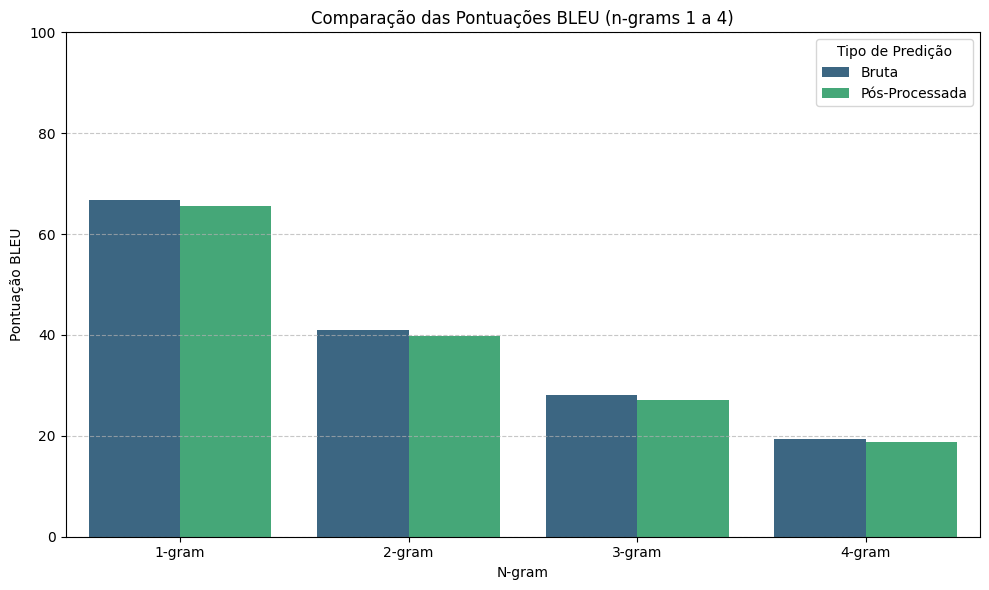

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract n-gram precisions
ngram_labels = ['1-gram', '2-gram', '3-gram', '4-gram']
raw_precisions = bleu_raw['precisions']
post_precisions = bleu_post['precisions']

# Create a DataFrame for plotting
data = {
    'N-gram': ngram_labels + ngram_labels,
    'Tipo de Predição': ['Bruta'] * len(ngram_labels) + ['Pós-Processada'] * len(ngram_labels),
    'Pontuação BLEU': raw_precisions + post_precisions
}
df_bleu_plot = pd.DataFrame(data)

# Plotting the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='N-gram', y='Pontuação BLEU', hue='Tipo de Predição', data=df_bleu_plot, palette='viridis')
plt.title('Comparação das Pontuações BLEU (n-grams 1 a 4)')
plt.ylabel('Pontuação BLEU')
plt.xlabel('N-gram')
plt.ylim(0, 100) # BLEU scores are usually between 0 and 100
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tipo de Predição')
plt.tight_layout()
plt.show()

In [96]:
print("Iniciando a geração de predições para o conjunto de validação...")
print(f"Tamanho do conjunto de validação: {len(tokenized_dataset['validation'])} amostras")

# Gerar predições com batch_size maior para acelerar a inferência
val_preds_raw, val_refs = generate_predictions(
    tokenized_dataset["validation"],
    batch_size=32,
    max_new_tokens=64
)

# Pós-processamento das predições
val_preds_post = [postprocess_portuguese(p) for p in val_preds_raw]

# Calcular as pontuações do SacreBLEU
val_bleu_raw = sacrebleu.compute(
    predictions=[p.strip() for p in val_preds_raw],
    references=[[r.strip()] for r in val_refs]
)

val_bleu_post = sacrebleu.compute(
    predictions=[p.strip() for p in val_preds_post],
    references=[[r.strip()] for r in val_refs]
)

print("\n--- Resultados da Avaliação (Validação) ---")
print(f"SacreBLEU Bruto: {val_bleu_raw['score']:.2f}")
print(f"SacreBLEU Pós-processado: {val_bleu_post['score']:.2f}")

Iniciando a geração de predições para o conjunto de validação...
Tamanho do conjunto de validação: 6367 amostras

--- Resultados da Avaliação (Validação) ---
SacreBLEU Bruto: 28.92
SacreBLEU Pós-processado: 28.97
